In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lmfit import Model
import pathlib as Path
from scipy.signal import savgol_filter

import src.modeling as mod

In [2]:
from pathlib import Path
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_08_08_data_timeseries.csv')
df = pd.read_csv(x)
df.head()

,condition_id,condition,category,valence,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix)
0,ACP_10,ACP,objet,negative,0.000000,-0.203103,10.545351,-1.557942,7.259980
1,ACP_10,ACP,objet,negative,0.003335,0.411109,11.118102,-0.912476,7.956384
2,ACP_10,ACP,objet,negative,0.006670,1.032096,11.620336,-0.216857,8.562834
3,ACP_10,ACP,objet,negative,0.010006,1.631694,11.941326,0.494356,8.978518
4,ACP_10,ACP,objet,negative,0.013341,2.171882,11.973220,1.177103,9.107632


In [3]:
df['RDX_rolling'] = df.groupby(['condition_id', 'category', 'valence'])['RDX (pix)'].transform(
    lambda x: x.rolling(window=20, min_periods=1).mean()
)

In [ ]:
sns.relplot(df[df.condition=='CTR'], x='time', y='RDX (pix)', col='condition_id', col_wrap=4, hue='valence', style='category', kind='line', errorbar=None)
plt.tight_layout()

latence au minimum, latence au maximum, pente de dilatation (2–4 s)

In [28]:
df['RDX_min'] = df.groupby(['condition_id', 'category', 'valence'])['RDX_rolling'].transform(
    lambda x: x.min()
)

df['RDX_lat_min'] = df.groupby(['condition_id', 'category', 'valence'])['RDX_rolling'].transform(
    lambda x: x.iloc[50:1700].argmin() + 50 if x.notna().any() else None
)

df['RDX_max'] = df.groupby(['condition_id', 'category', 'valence'])['RDX_rolling'].transform(
    lambda x: x.iloc[350:1750].max()
)

df['RDX_lat_max'] = df.groupby(['condition_id', 'category', 'valence'])['RDX_rolling'].transform(
    lambda x: x.iloc[350:1750].argmax() + 350 if x.notna().any() else None
)

# gradient of curve between 2 and 4 seconds
df['RDX_grad'] = df.groupby(['condition_id', 'category', 'valence'])['RDX_rolling'].transform(
    lambda x: (x.iloc[1200]-x.iloc[300])/900 if x.notna().any() else None
)

<Axes: xlabel='condition', ylabel='RDX_grad'>

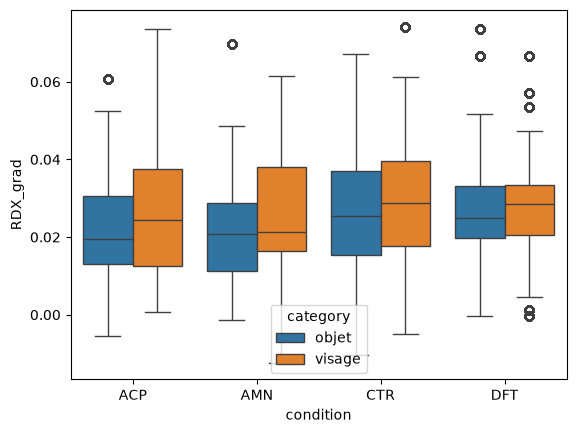

In [144]:
sns.boxplot(df, x='condition', y='RDX_grad', hue='category')
# sns.boxplot?